# Введение
## Цель
Изучение методов классификации данных, реализованные в библиотеке Scikit-Learn, а также ознакомление с нейронными сетями с использованием библиотек TensorFlow и TensorBoard. 
## Задачи
1. Необходимо выбрать и подготовить датасет для классификации, затем построить классификационные модели с помощью пяти методов:
    - Наивный Байесовский классификатор (GaussianNB, MultinomialNB, ComplementNB, BernoulliNB);
    - Деревья решений (Decision Tree);
    - Линейный дискриминантный анализ (Linear Discriminant Analysis);
    - Метод опорных векторов (Support Vector Machines);
    - Метод ближайших соседей (k-Nearest Neighbors);
2. Затем сравните качество работы классификаторов с помощью следующих метрик:
    - Accuracy (точность),
    - Precision (доля правильно классифицированных положительных примеров),
    - Recall (чувствительность, доля верно найденных положительных примеров),
    - F1-Score (среднее гармоническое precision и recall),
    - Площадь под кривой ROC (AUC-ROC).
3. Настройте гиперпараметры каждого метода и проведите исследование влияния различных параметров на качество классификации.
4. Реализуйте и протестируйте нейронную сеть на TensorFlow, исследуйте эффект настройки гиперпараметров и визуализируйте процесс обучения с помощью инструмента TensorBoard.

# Выбор и подготовка датасета
## Описание датасета
Для работы выбран датасет [Wine Quality Dataset](https://www.kaggle.com/datasets/yasserh/wine-quality-dataset). 

Этот датасет содержит информацию о красных винах португальского региона "Винью Верде". Данные были собраны в результате физико-химических лабораторных тестов, а целевая переменная (качество) основана на сенсорной оценке (дегустации).
Признаки:
1. fixed acidity - титруемая кислотность
2. volatile acidity - летучая кислотность
3. citric acid - лимонная кислота
4. residual sugar - остаточный сахар
5. chlorides - хлориды
6. free sulfur dioxide - свободный диоксид серы
7. total sulfur dioxide - общий диоксид серы
8. density - плотность
9. pH - водородный показатель
10. sulphates - сульфаты
11. alcohol - алкоголь (в %)
12. quality - качество (от 0 до 10)

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import kagglehub
import seaborn as sb
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.preprocessing import StandardScaler
import math
import scipy.stats as stats

file_path = "WineQT.csv"

df = kagglehub.dataset_load(
  kagglehub.KaggleDatasetAdapter.PANDAS,
  "yasserh/wine-quality-dataset",
  file_path,
)

df = df.drop(columns=["Id"]) # Убираю id записи, не понадобится
display(df.head())

c:\Users\bulch\OneDrive\Desktop\Нейронки\ML\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


## Анализ параметров

,Признак,Среднее,Медиана,Мода,Минимум,Максимум,Стандартное отклонение,Дисперсия,Асимметрия,Эксцесс,"Квантили (25%, 50%, 75%)",Оценка нормальности распредления (тест Колмагорова-Смирнова)
0,Титруемая кислотность (fixed acidity),8.31,7.90,7.20,4.60,15.90,1.75,3.05,1.04,1.38,"{0.25: 7.1, 0.5: 7.9, 0.75: 9.1}",p=4.679e-12 → Далеко от нормального
1,Летучая кислотность (volatile acidity),0.53,0.52,0.50,0.12,1.58,0.18,0.03,0.68,1.38,"{0.25: 0.3925, 0.5: 0.52, 0.75: 0.64}",p=5.665e-03 → Далеко от нормального
2,Лимонная кислота (citric acid),0.27,0.25,0.00,0.00,1.00,0.20,0.04,0.37,-0.71,"{0.25: 0.09, 0.5: 0.25, 0.75: 0.42}",p=7.683e-08 → Далеко от нормального
3,Остаточный сахар (residual sugar),2.53,2.20,2.00,0.90,15.50,1.36,1.84,4.36,27.68,"{0.25: 1.9, 0.5: 2.2, 0.75: 2.6}",p=5.887e-68 → Далеко от нормального
4,Хлориды (chlorides),0.09,0.08,0.08,0.01,0.61,0.05,0.00,6.03,47.08,"{0.25: 0.07, 0.5: 0.079, 0.75: 0.09}",p=1.097e-67 → Далеко от нормального
5,Свободный диоксид серы (free sulfur dioxide),15.62,13.00,6.00,1.00,68.00,10.25,105.07,1.23,1.93,"{0.25: 7.0, 0.5: 13.0, 0.75: 21.0}",p=1.948e-12 → Далеко от нормального
6,Общий диоксид серы (total sulfur dioxide),45.91,37.00,28.00,6.00,289.00,32.78,1074.67,1.67,5.10,"{0.25: 21.0, 0.5: 37.0, 0.75: 61.0}",p=4.584e-15 → Далеко от нормального
7,Плотность (density),1.00,1.00,1.00,0.99,1.00,0.00,0.00,0.10,0.89,"{0.25: 0.99557, 0.5: 0.99668, 0.75: 0.997845}",p=2.312e-02 → Близко к нормальному
8,Водородный показатель (pH),3.31,3.31,3.30,2.74,4.01,0.16,0.02,0.22,0.93,"{0.25: 3.205, 0.5: 3.31, 0.75: 3.4}",p=1.425e-02 → Близко к нормальному
9,Сульфаты (sulphates),0.66,0.62,0.60,0.33,2.00,0.17,0.03,2.50,12.02,"{0.25: 0.55, 0.5: 0.62, 0.75: 0.73}",p=2.989e-17 → Далеко от нормального


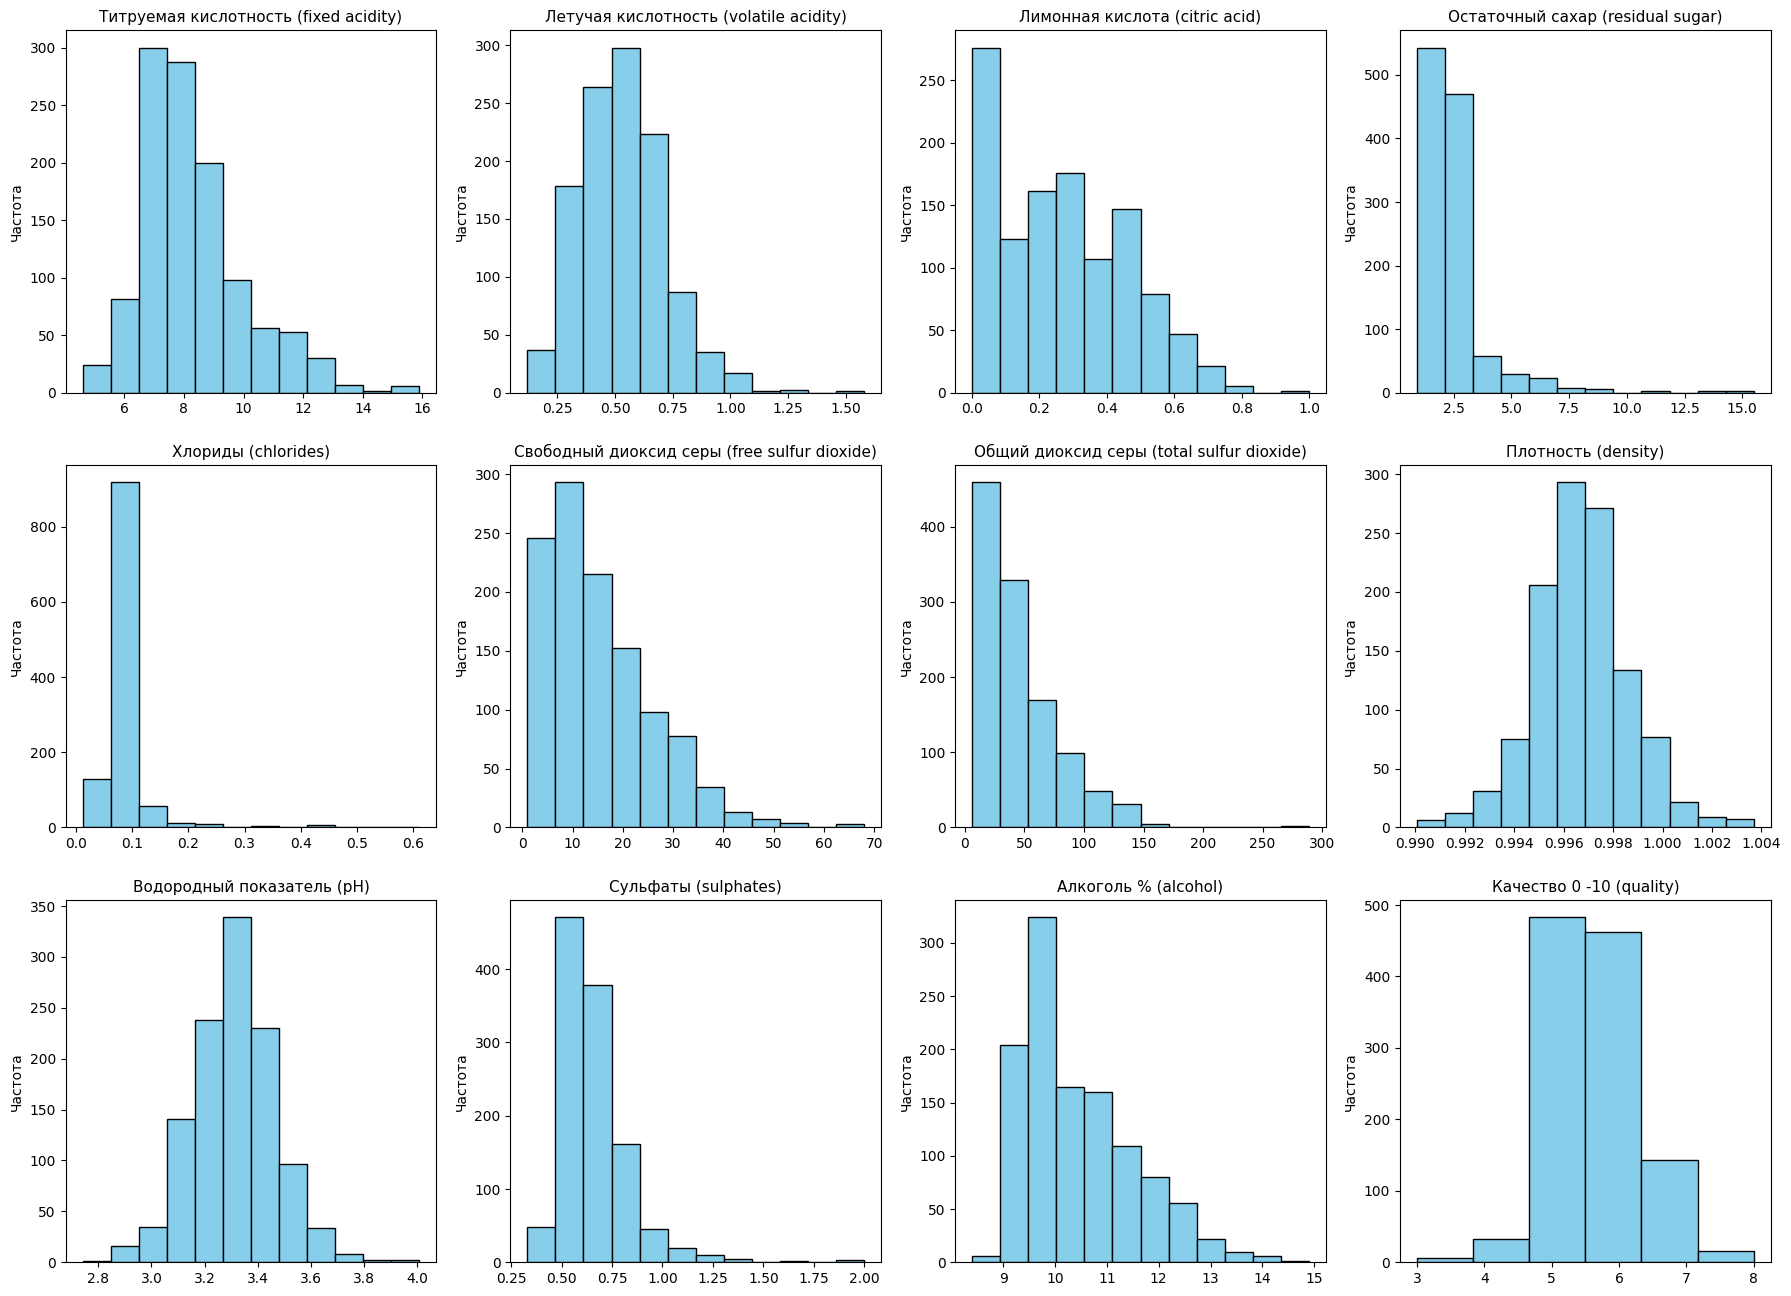

In [3]:
n = df.shape[0]
k = int(math.ceil(1 + math.log2(n)))

def interpret_pvalue(p):
     if p > 0.05:
         return "Нормальное"
     elif p > 0.01:
         return "Близко к нормальному"
     else:
         return "Далеко от нормального"
     
translate = {
    "fixed acidity" : "Титруемая кислотность (fixed acidity)",
    "volatile acidity" : "Летучая кислотность (volatile acidity)",
    "citric acid" : "Лимонная кислота (citric acid)",
    "residual sugar" : "Остаточный сахар (residual sugar)",
    "chlorides" : "Хлориды (chlorides)",
    "free sulfur dioxide" : "Свободный диоксид серы (free sulfur dioxide)",
    "total sulfur dioxide" : "Общий диоксид серы (total sulfur dioxide)",
    "density" : "Плотность (density)",
    "pH" : "Водородный показатель (pH)",
    "sulphates" : "Сульфаты (sulphates)",
    "alcohol" : "Алкоголь % (alcohol)",
    "quality" : "Качество 0 -10 (quality)"
}

features = df.columns
fig, axes = plt.subplots(3, 4, figsize=(22, 16))
axes = axes.flatten()

stat = {
    "Признак": [], "Среднее": [], "Медиана": [], "Мода": [], "Минимум": [], "Максимум": [],
    "Стандартное отклонение": [], "Дисперсия": [], "Асимметрия": [], "Эксцесс": [], "Квантили (25%, 50%, 75%)": [],
    "Оценка нормальности распредления (тест Колмагорова-Смирнова)": []
    }

for i, feature in enumerate(features):
    ks_test = stats.kstest(df[feature], 'norm', args=(df[feature].mean(), df[feature].std()))

    # Собируем статистику
    stat["Признак"].append(translate[feature])
    stat["Среднее"].append(round(df[feature].mean(), 2))
    stat["Медиана"].append(round(df[feature].median(), 2))
    stat["Мода"].append(round(df[feature].mode()[0], 2))
    stat["Минимум"].append(round(df[feature].min(), 2))
    stat["Максимум"].append(round(df[feature].max(), 2))
    stat["Стандартное отклонение"].append(round(df[feature].std(), 2))
    stat["Дисперсия"].append(round(df[feature].var(), 2))
    stat["Асимметрия"].append(round(df[feature].skew(), 2))
    stat["Эксцесс"].append(round(df[feature].kurtosis(), 2))
    stat["Квантили (25%, 50%, 75%)"].append(df[feature].quantile([0.25, 0.5, 0.75]).to_dict())
    stat["Оценка нормальности распредления (тест Колмагорова-Смирнова)"].append(f"p={ks_test.pvalue:.3e} → {interpret_pvalue(ks_test.pvalue)}")


    # Строим гистограммы для всех признаков
    k_ = k if feature != "quality" else 6
    axes[i].hist(df[feature], bins=k_, edgecolor='black', color='skyblue')
    axes[i].set_title(translate[feature], fontsize=11)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Частота")

display(pd.DataFrame(stat))

Отсюда видна большая проблема - у quality очень маленькая частота для 3. Поменяем качество 3 -> 4, а так же приведем к 5-бальной шкале (от 1 до 5).

,Признак,Среднее,Медиана,Мода,Минимум,Максимум,Стандартное отклонение,Дисперсия,Асимметрия,Эксцесс,"Квантили (25%, 50%, 75%)",Оценка нормальности распредления (тест Колмагорова-Смирнова)
0,Качество 1-5 (quality),2.66,3.0,2,1,5,0.79,0.63,0.43,-0.02,"{0.25: 2.0, 0.5: 3.0, 0.75: 3.0}",p=3.651e-66 → Далеко от нормального


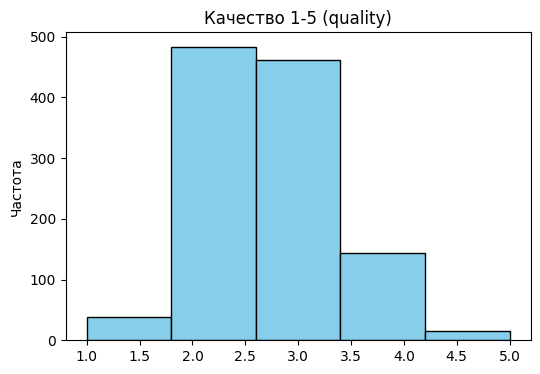

In [4]:
y = df['quality'].map({3: 1, 4: 1, 5: 2, 6: 3, 7: 4, 8: 5})
df['quality'] = y

translate['quality'] = "Качество 1-5 (quality)"
feature = 'quality'
ks_test = stats.kstest(df[feature], 'norm', args=(df[feature].mean(), df[feature].std()))

stat = {
    "Признак": translate[feature],
    "Среднее": round(df[feature].mean(), 2),
    "Медиана": round(df[feature].median(), 2),
    "Мода": round(df[feature].mode()[0], 2),
    "Минимум": round(df[feature].min(), 2),
    "Максимум": round(df[feature].max(), 2),
    "Стандартное отклонение": round(df[feature].std(), 2),
    "Дисперсия": round(df[feature].var(), 2),
    "Асимметрия": round(df[feature].skew(), 2),
    "Эксцесс": round(df[feature].kurtosis(), 2),
    "Квантили (25%, 50%, 75%)": df[feature].quantile([0.25, 0.5, 0.75]).to_dict(),
    "Оценка нормальности распредления (тест Колмагорова-Смирнова)": f"p={ks_test.pvalue:.3e} → {interpret_pvalue(ks_test.pvalue)}"
}

# Вывод таблицы
display(pd.DataFrame([stat]))

# Гистограмма
plt.figure(figsize=(6,4))
plt.hist(df[feature], bins=5, edgecolor='black', color='skyblue')
plt.title(translate[feature])
plt.ylabel('Частота')
plt.show()


# Разбиение выборки

In [5]:
X = df.drop(columns=["quality"])
y = df["quality"]  

# Разбиение на обучающую и тестовую выборки (70/30)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Стандартизированный вариант
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# Методы классификации

Заранее подготовим функцию для вывода метрик.

In [6]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_fscore_support, accuracy_score, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve
from sklearn.preprocessing import label_binarize

def get_metrics(y_true, y_pred, y_score, class_names=None):
    classes = np.unique(y_true)
    names  = class_names or [str(c) for c in classes]
    avgs   = ['micro','macro','weighted']
    acc    = accuracy_score(y_true, y_pred)

    p_c, r_c, f_c, _ = precision_recall_fscore_support(y_true, y_pred, labels=classes, average=None, zero_division=0)
    y_bin  = label_binarize(y_true, classes=classes)
    auc_c  = [roc_auc_score(y_bin[:, i], y_score[:, i]) for i in range(len(classes))]

    cols = ['Precision','Recall','F1','Accuracy','ROC AUC']
    df_classes = pd.DataFrame(np.column_stack([p_c, r_c, f_c, np.full_like(p_c, np.nan), auc_c]), index=names, columns=cols)
    df_aggs = pd.DataFrame([[*precision_recall_fscore_support(y_true, y_pred, average=a, zero_division=0)[:3],
                              acc, roc_auc_score(y_true, y_score, multi_class='ovr', average=a)] for a in avgs],
                           index=avgs, columns=cols)

    df = pd.concat([df_classes, df_aggs])
    for c in ['Precision','Recall','F1','ROC AUC']:
        df[c] = df[c].astype(float).round(4)

    df['Accuracy'] = df['Accuracy'].astype('object')
    df.loc[names, 'Accuracy'] = ''                                
    df.loc[avgs,  'Accuracy'] = df.loc[avgs, 'Accuracy'].astype(float).round(4)
    display(df)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    ConfusionMatrixDisplay(confusion_matrix(y_true, y_pred, labels=classes), display_labels=names)\
        .plot(ax=axes[0], cmap='Blues', colorbar=False)
    axes[0].set_title('Матрица ошибок')

    for i, name in enumerate(names):
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_score[:, i])
        axes[1].plot(fpr, tpr, lw=2, label=name)
    axes[1].plot([0,1],[0,1],'--', lw=1)
    axes[1].set(xlabel='FPR', ylabel='TPR', title='ROC (OvR)')
    axes[1].legend(loc='lower right')
    plt.tight_layout(); plt.show()

    return df


## 1.Наивный Байесовский классификатор
Есть 4 разновидности этого метода
- GaussianNB - непрерывные (вещественные) признаки,
- MultinomialNB - счётчики (тексты), целые числа,
- ComplementNB - тоже счётчики, но с фокусом на дисбаланс (модификация Multinomial),
- BernoulliNB - бинарные признаки (0/1).
Так как у нас вещественные числа, то единственным подходящим вариантом становится GaussianNB.

Как работает:
1. GaussianNB вычисляет среднее и дисперсию каждого признака внутри каждого класса.
2. Для нового объекта считает, насколько его признаки «подходят» под нормальное распределение каждого класса.
3. Выбирает класс с наибольшей вероятностью.



### Подбор лучших параметров
Будем перебирать признак var_smoothing - добавочная дисперсия

,var_smoothing,accuracy
0,0.000000e+00,0.565598
1,1.000000e-15,0.565598
2,1.000000e-14,0.565598
3,1.000000e-13,0.565598
4,1.000000e-12,0.565598
5,1.000000e-11,0.565598
6,1.000000e-10,0.565598
7,1.000000e-09,0.565598
8,1.000000e-08,0.565598
9,1.000000e-07,0.565598


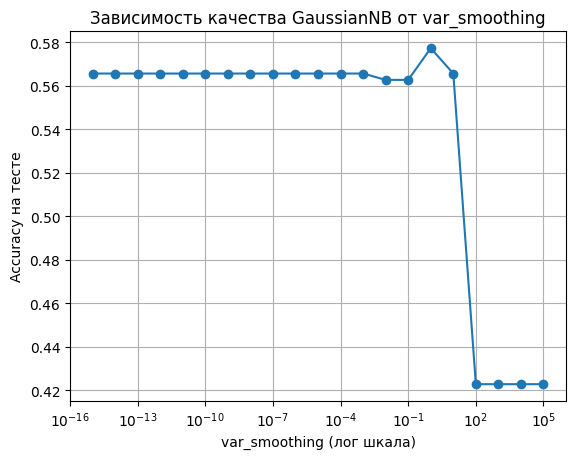

In [38]:
from sklearn.naive_bayes import GaussianNB

vs_values = np.concatenate([
    [0.0],
    np.logspace(-15, -1, 15),
    np.logspace(0, 5, 6)
])

results = []

for vs in vs_values:
    model = GaussianNB(var_smoothing=vs)
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)
    results.append({
        "var_smoothing": vs,
        "accuracy": acc
    })

results_df = (
    pd.DataFrame(results)
    .sort_values(by="var_smoothing")
    .reset_index(drop=True)
)

display(results_df)

mask_pos = results_df["var_smoothing"] > 0 
plt.figure()
plt.semilogx(
    results_df.loc[mask_pos, "var_smoothing"],
    results_df.loc[mask_pos, "accuracy"],
    marker="o"
)
plt.xlabel("var_smoothing (лог шкала)")
plt.ylabel("Accuracy на тесте")
plt.title("Зависимость качества GaussianNB от var_smoothing")
plt.grid(True)
plt.show()


- При малых значениях (0…1e-4) качество классификации остаётся постоянным (accuracy ≈ 0.5656).
Это означает, что исходные дисперсии достаточно большие, и добавляемое сглаживание практически не влияет на модель.

- При значениях 1e-2…1e-1 наблюдается небольшое снижение точности.
Это связано с тем, что распределения становятся шире, и модель хуже разделяет классы.

- Оптимальное значение — var_smoothing = 1,
при котором достигается максимальная точность accuracy = 0.5773.

- При больших значениях (1e2…1e5) качество резко падает (accuracy ≈ 0.4227).
В этом диапазоне сглаживание становится чрезмерным, распределения разных классов становятся почти одинаковыми, и модель теряет информативность признаков.

### Решение задачи классификации

,Precision,Recall,F1,Accuracy,ROC AUC
1,0.3333,0.0833,0.1333,,0.6767
2,0.6395,0.7586,0.6940,,0.7858
3,0.5419,0.6087,0.5734,,0.6794
4,0.2308,0.0698,0.1071,,0.8450
5,0.0000,0.0000,0.0000,,0.8746
micro,0.5773,0.5773,0.5773,0.5773,0.8626
macro,0.3491,0.3041,0.3016,0.5773,0.7723
weighted,0.5290,0.5773,0.5422,0.5773,0.7479


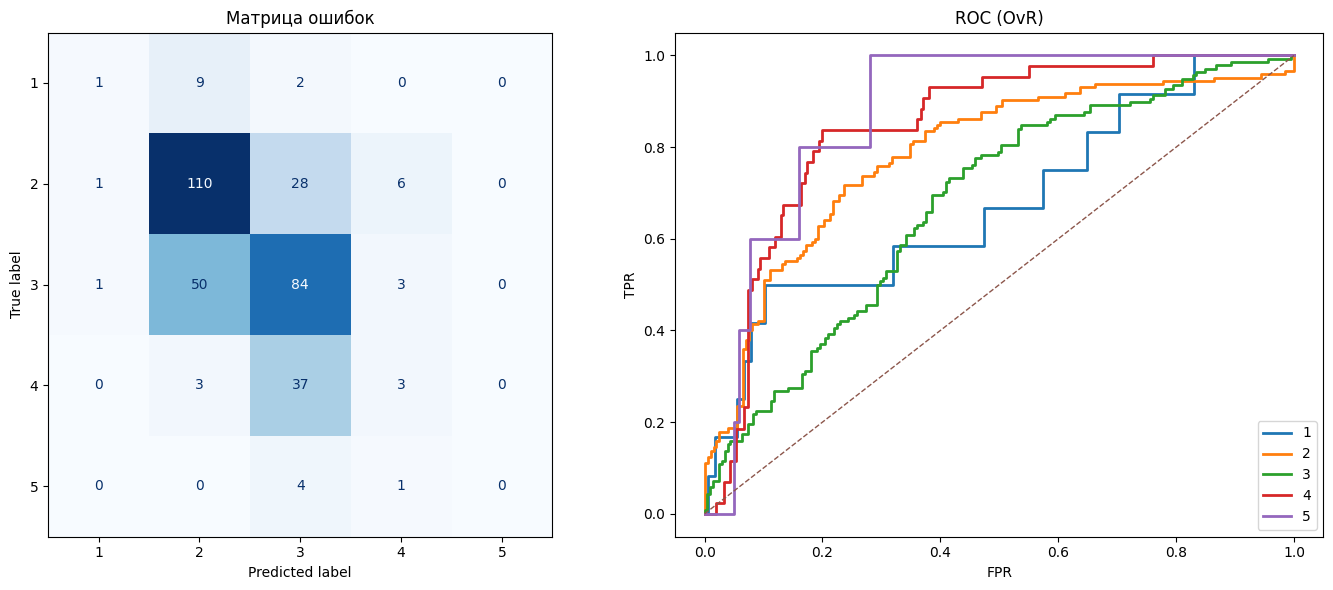

In [48]:
clf = GaussianNB(var_smoothing=1)
clf.fit(X_train_scaled, y_train)  

y_pred = clf.predict(X_test_scaled)
y_prob = clf.predict_proba(X_test_scaled)

tree_metrics = get_metrics(y_test, y_pred, y_prob, class_names=['1', '2', '3', '4', '5'])

Видим что модель дает низкую точность, и для решения наших задач не очень подходит. Вероятно это из-за того что алгоритм требует нормальное распредление - что у нас не соблюдено.

## 2. Дерево решений

Как строится дерево:
1. Считаем значение критерия в узле. Среди кретериев используется Gini и Entropy:

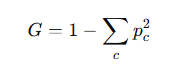
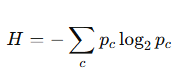

2. Составляется список правил по типу <значение> <= <параметр>.
3. Для каждого правило считается качество разделения 

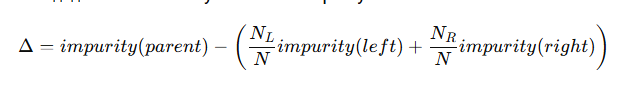

(impurity - выбранный критерий)

4. Выбираем правило с наибольшим качеством разделения, составляем 2 новых узлы и для каждого повторяем действия 1 - 4.
5. Остановка происходит: 
    - в момент, когда impurity на узле = 0 (это значит что в узле все принадлежит одному классу) 
    - достигили max_depth - максимальной глубины дерева.
    - в узле слишком мало объектов, т.е. <количество_объектов> < min_samples_split (2 по умолчанию)
    - если при разбиении будет создан узел в котором будет меньше оббъектов чем указано в min_samples_leaf
    - невозможно улучшить критерий Gini/Entropy


### Подбор лучших параметров
Будем перебирать следующие критерии:
- criterion — критерий качества разбиения (gini/entropy)
- max_depth — максимальная глубина дерева

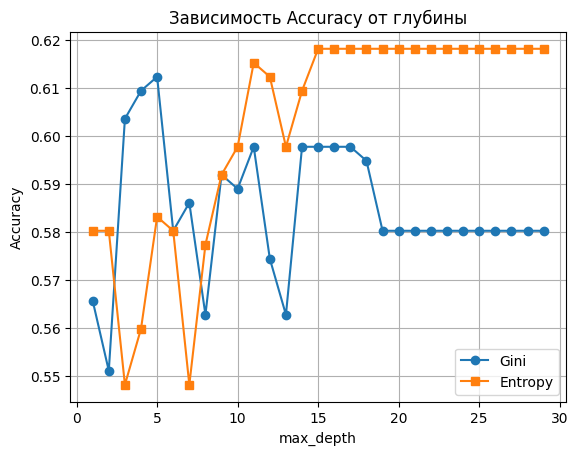

In [75]:
from sklearn.tree import DecisionTreeClassifier

depth_values = list(range(1, 30))

acc_gini = []
acc_entropy = []

for depth in depth_values:
    clf_gini = DecisionTreeClassifier(
        criterion="gini",
        max_depth=depth,
        random_state=42
    )
    clf_gini.fit(X_train, y_train)
    y_pred_gini = clf_gini.predict(X_test)
    acc_gini.append(accuracy_score(y_test, y_pred_gini))

    clf_entropy = DecisionTreeClassifier(
        criterion="entropy",
        max_depth=depth,
        random_state=42
    )
    clf_entropy.fit(X_train, y_train)
    y_pred_entropy = clf_entropy.predict(X_test)
    acc_entropy.append(accuracy_score(y_test, y_pred_entropy))

# График
plt.figure()
plt.plot(depth_values, acc_gini, marker="o", label="Gini")
plt.plot(depth_values, acc_entropy, marker="s", label="Entropy")
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("Зависимость Accuracy от глубины")
plt.grid(True)
plt.legend()
plt.show()

Мы видим что для энтропии с 15 дерево никак не меняется, у джини с 19. У джини после 5 резко ухудшается качество, можно сказать что модель начинает переобучаться. У энтропии это начинается с 11. Лучшим решением будет взять gini и max_depth = 5/

### Решение задачи классификации

,Precision,Recall,F1,Accuracy,ROC AUC
1,0.0000,0.0000,0.0000,,0.5228
2,0.6494,0.7793,0.7085,,0.7734
3,0.5755,0.5797,0.5776,,0.6705
4,0.5667,0.3953,0.4658,,0.8416
5,0.0000,0.0000,0.0000,,0.8956
micro,0.6122,0.6122,0.6122,0.6122,0.8643
macro,0.3583,0.3509,0.3504,0.6122,0.7408
weighted,0.5771,0.6122,0.5903,0.6122,0.7336


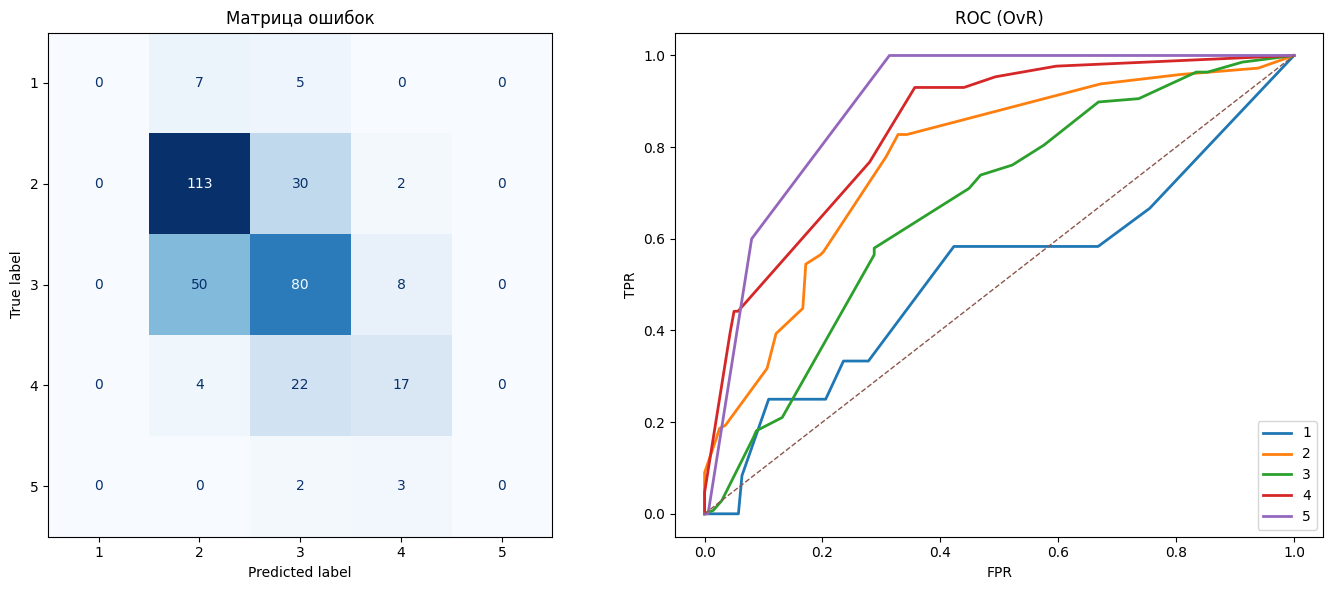

In [76]:
from sklearn.tree import DecisionTreeClassifier

clf = DecisionTreeClassifier(random_state=42, max_depth=5)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)

tree_metrics = get_metrics(y_test, y_pred, y_prob, class_names=['1', '2', '3', '4', '5'])

### Визуализация дерева решения

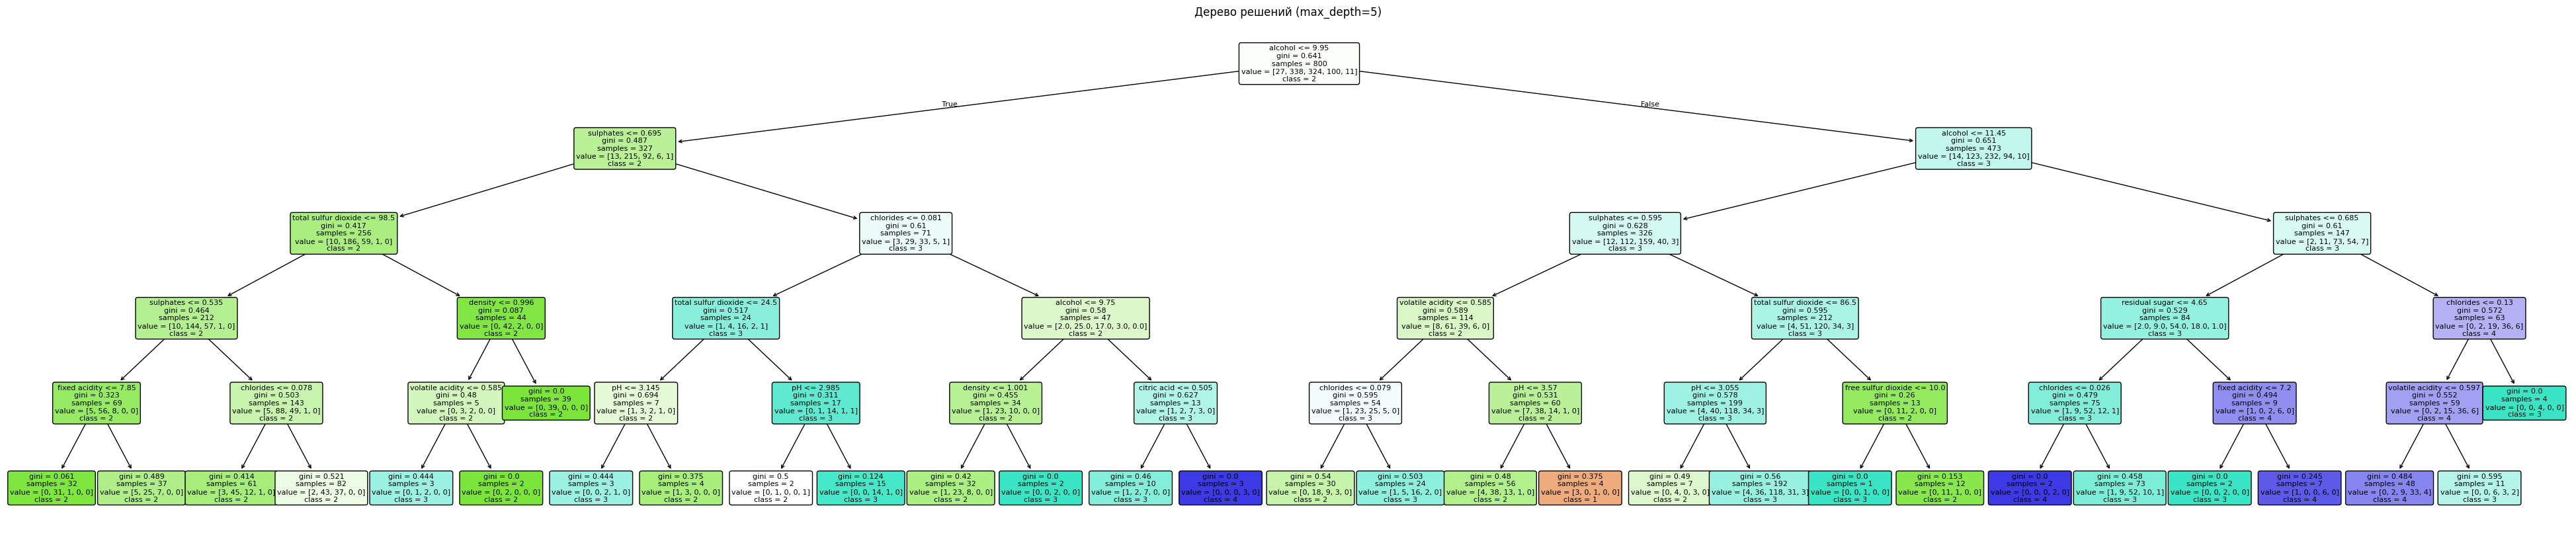

In [88]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(50, 10))  

plot_tree(
    clf,
    feature_names=X.columns,              
    class_names=['1', '2', '3', '4', '5'],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.title("Дерево решений (max_depth=5)")
plt.show()

## 3. Линейный дискриминантный анализ

### Подбор лучших параметров

### Решение задачи классификации

## 4. Метод опорных векторов

### Подбор лучших параметров

### Решение задачи классификации

## 5. Метод ближайших соседей

### Подбор лучших параметров

### Решение задачи классификации